In [1]:
import requests, json, time, tqdm
import pandas as pd
import matplotlib as mb
import numpy as np

def get_data(ticker, period = "h6"):
    url = f"https://tornsy.com/api/{ticker}?interval={period}"
    response = requests.get(url)
    if response.status_code != 200:
        raise Exception(f"Failed to fetch data for {ticker}. Status code: {response.status_code}")
    data = response.json()
    # print(data)
    df = pd.DataFrame(data["data"], columns=["Timestamp", "Opening Price", "Closing Price", "High Price", "Low Price", "No of Shares"])
    df = df.sort_values(by="Timestamp", ascending=True)
    return df

In [2]:
def normalize(series, max, min):
    series = series.astype(float)
    norm_series = (series - min) / (max - min)
    return norm_series




In [3]:
import matplotlib.pyplot as plt
def plot(series_list):
    # plot all series in the same figure
    plt.figure(figsize=(10, 5))
    for series in series_list:
        plt.plot(series, label=series.name)
    plt.xlabel('Time')
    plt.ylabel('Normalized Value')
    plt.title('Normalized Stock Prices')
    plt.legend()
    plt.grid()
    plt.show()



In [4]:
def get_normalized_data(tickers):
    series_list = []
    for ticker in tqdm.tqdm(tickers):
        data = get_data(ticker)
        price = data["Low Price"].astype(float)
        # print(price)
        max_price = price.max()
        min_price = price.min()
        normalized_data = normalize(price, max_price, min_price)
        series_list.append(normalized_data)
        time.sleep(1)
    return series_list



100%|██████████| 2/2 [00:02<00:00,  1.47s/it]


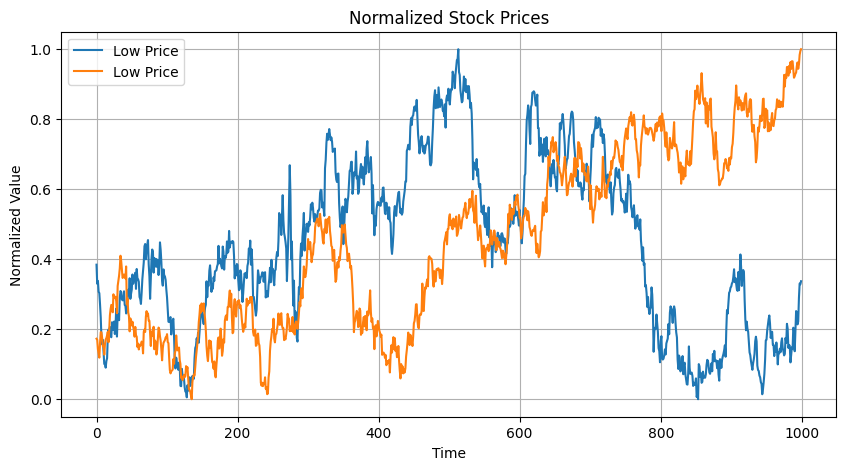

In [ ]:
plot(get_normalized_data(["LAG", "ASS"]))

In [5]:
stockNames = [
    "TSB",
    "TCI",
    "SYS",
    "LAG",
    "IOU",
    "GRN",
    "THS",
    "YAZ",
    "TCT",
    "CNC",
    "MSG",
    "TMI",
    "TCP",
    "IIL",
    "FHG",
    "SYM",
    "LSC",
    "PRN",
    "EWM",
    "TCM",
    "ELT",
    "HRG",
    "TGP",
    "MUN",
    "WSU",
    "IST",
    "BAG",
    "EVL",
    "MCS",
    "WLT",
    "TCC",
    "ASS",
    "CBD",
    "LOS",
    "PTS"
]


all_data = get_normalized_data(stockNames)

100%|██████████| 35/35 [01:08<00:00,  1.95s/it]


In [ ]:

def plot_all_combinations():
    series_list = all_data
    for i in range(len(series_list)):
        for j in range(i + 1, len(series_list)):
            plt.figure(figsize=(10, 5))
            plt.plot(series_list[i], label=stockNames[i])
            plt.plot(series_list[j], label=stockNames[j])
            plt.xlabel('Time')
            plt.ylabel('Normalized Value')
            plt.title(f'Normalized Stock Prices: {stockNames[i]} vs {stockNames[j]}')
            plt.legend()
            plt.grid()
            plt.show()

plot_all_combinations()


# plot_all_stocks()

In [ ]:

import matplotlib.pyplot as plt
def smooth_data(series, window_size=5):
  return series.rolling(window=window_size).mean()

smoothed_data = []
for series in all_data:
  smoothed_data.append(smooth_data(series))

def plot_smoothed_combinations():
  series_list = smoothed_data
  for i in range(len(series_list)):
    for j in range(i + 1, len(series_list)):
      plt.figure(figsize=(10, 5))
      plt.plot(series_list[i], label=f'{stockNames[i]} (Smoothed)')
      plt.plot(series_list[j], label=f'{stockNames[j]} (Smoothed)')
      plt.xlabel('Time')
      plt.ylabel('Normalized Value (Smoothed)')
      plt.title(f'Normalized Stock Prices (Smoothed): {stockNames[i]} vs {stockNames[j]}')
      plt.legend()
      plt.grid()
      plt.show()

plot_smoothed_combinations()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 3.0 MB/s eta 0:00:00
DTW Distance Matrix:
[[0.         1.98604765 2.42473233 ... 5.74697362 2.60619627 4.57578424]
 [1.98604765 0.         1.39970276 ... 6.57892085 1.44699762 5.66581015]
 [2.42473233 1.39970276 0.         ... 7.71789973 1.31037407 7.10577472]
 ...
 [5.74697362 6.57892085 7.71789973 ... 0.         8.3105943  3.6142078 ]
 [2.60619627 1.44699762 1.31037407 ... 8.3105943  0.         7.16322821]
 [4.57578424 5.66581015 7.10577472 ... 3.6142078  7.16322821 0.        ]]

Most Similar Pairs (based on minimum DTW distance):
Pair: YAZ and TGP, DTW Distance: 0.9625703722249023


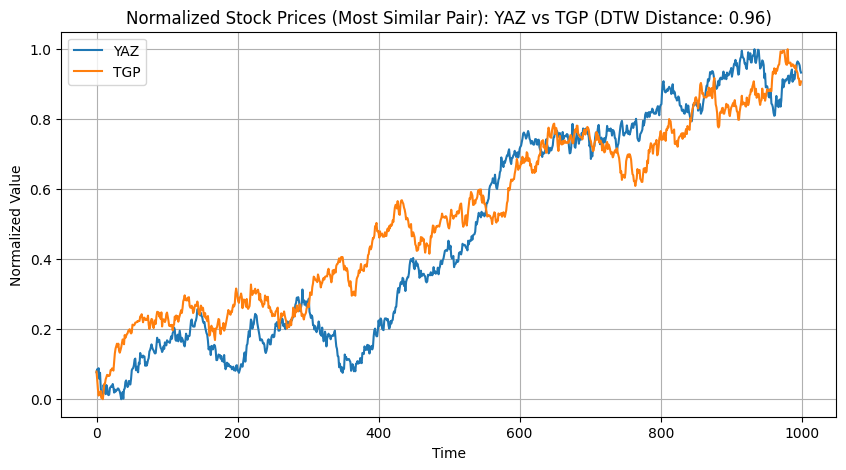

In [7]:

import matplotlib.pyplot as plt
import numpy as np
# !pip install tslearn
from tslearn.metrics import dtw

dtw_matrix = np.zeros((len(all_data), len(all_data)))

for i in range(len(all_data)):
    for j in range(len(all_data)):
        dtw_matrix[i, j] = dtw(all_data[i], all_data[j])

print("DTW Distance Matrix:")
print(dtw_matrix)

# Find the most similar pairs
most_similar_pairs = []
# Initialize with a large value to ensure the first valid pair becomes the minimum
min_distance = float('inf')
for i in range(len(all_data)):
    for j in range(i + 1, len(all_data)): # Avoid comparing a stock with itself and avoid duplicates
        if dtw_matrix[i, j] < min_distance:
            min_distance = dtw_matrix[i, j]
            most_similar_pairs = [(i, j)]
        elif dtw_matrix[i, j] == min_distance:
            most_similar_pairs.append((i, j))

print("\nMost Similar Pairs (based on minimum DTW distance):")
for i, j in most_similar_pairs:
    print(f"Pair: {stockNames[i]} and {stockNames[j]}, DTW Distance: {dtw_matrix[i, j]}")

# Plot the most similar pairs
for i, j in most_similar_pairs:
    plt.figure(figsize=(10, 5))
    plt.plot(all_data[i], label=stockNames[i])
    plt.plot(all_data[j], label=stockNames[j])
    plt.xlabel('Time')
    plt.ylabel('Normalized Value')
    plt.title(f'Normalized Stock Prices (Most Similar Pair): {stockNames[i]} vs {stockNames[j]} (DTW Distance: {dtw_matrix[i, j]:.2f})')
    plt.legend()
    plt.grid()
    plt.show()


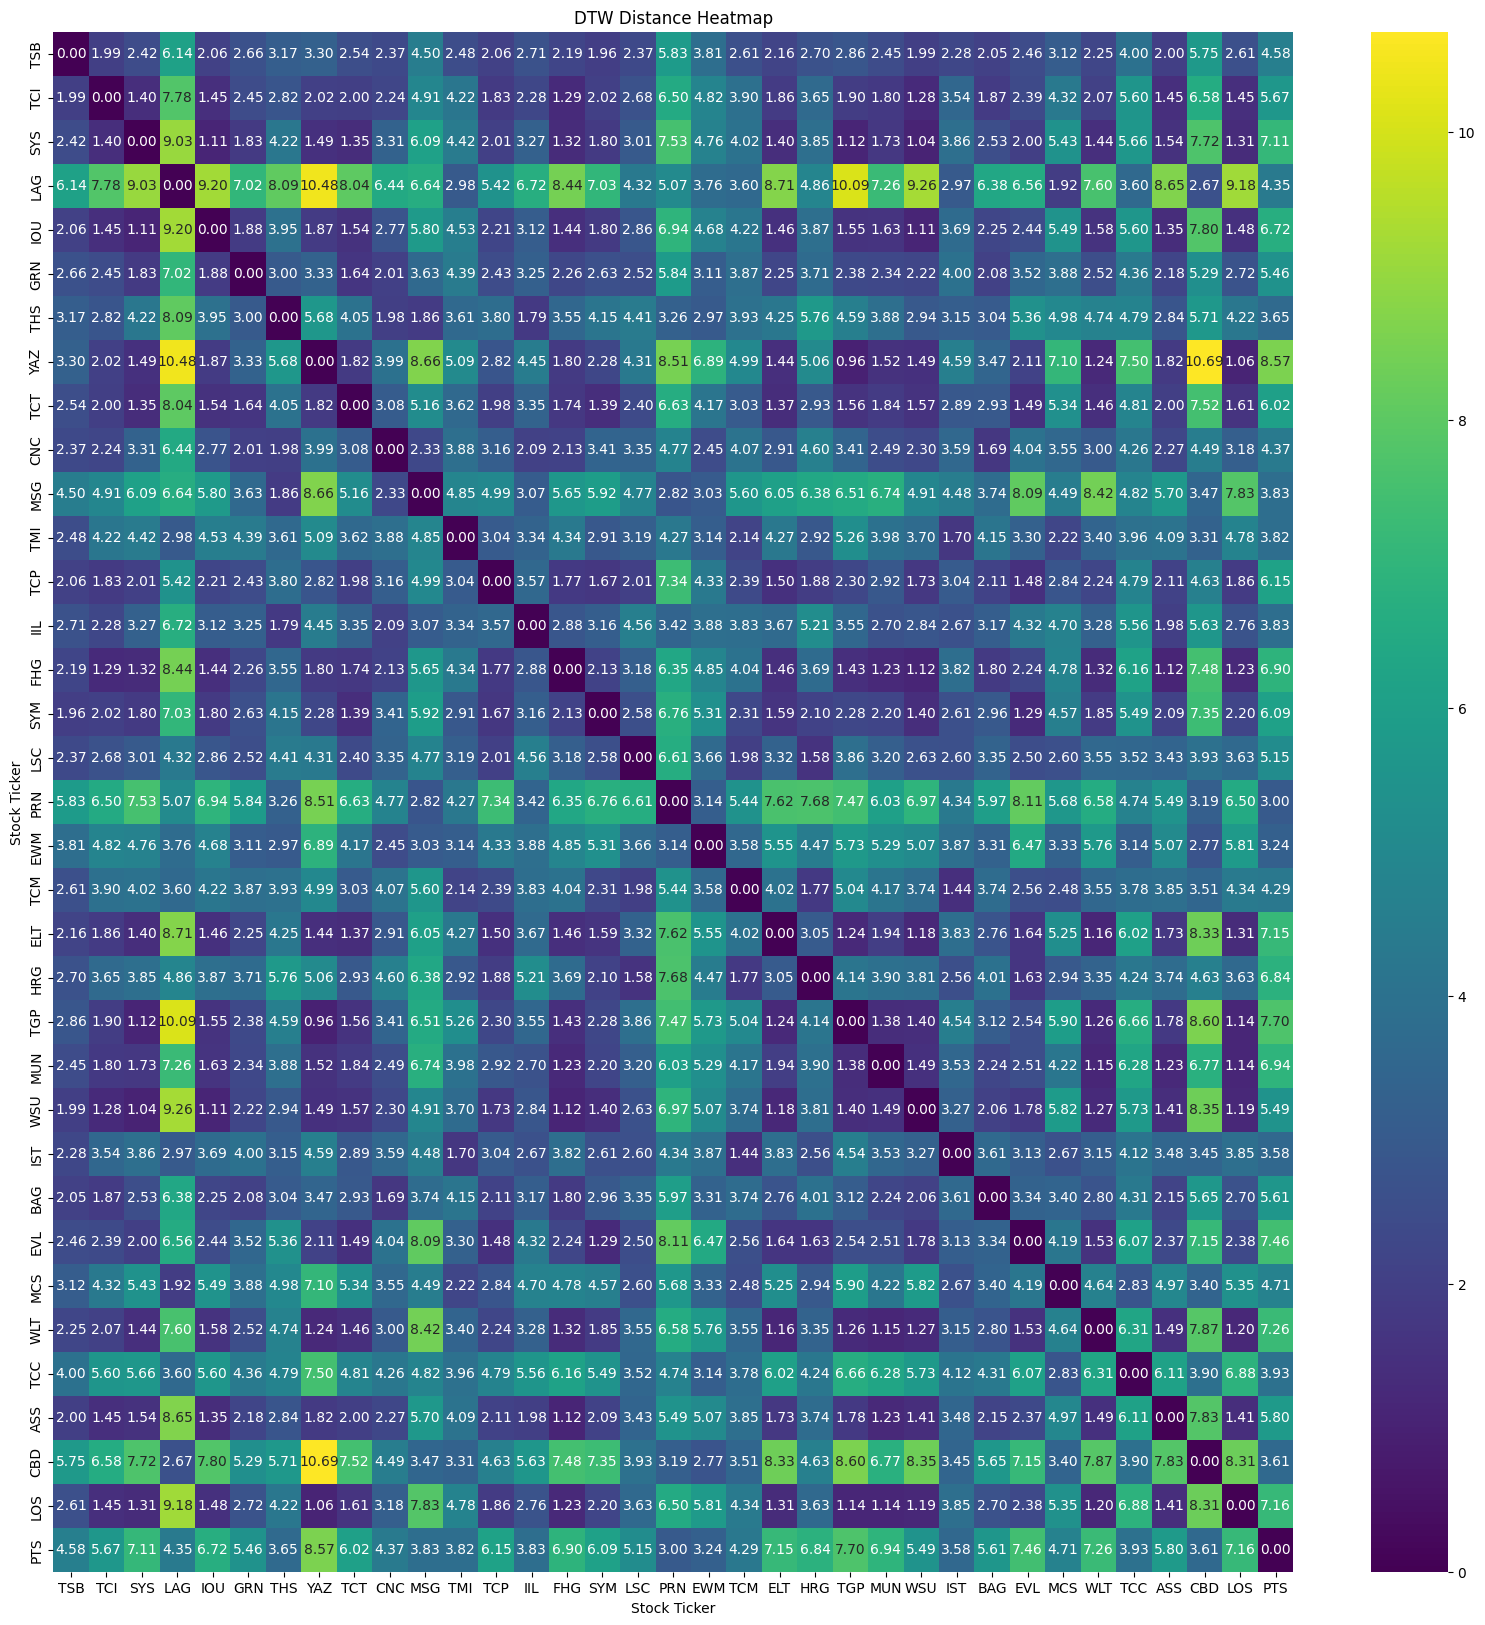

In [13]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 20))
sns.heatmap(dtw_matrix, annot=True, xticklabels=stockNames, yticklabels=stockNames, cmap='viridis', fmt=".2f")
plt.title('DTW Distance Heatmap')
plt.xlabel('Stock Ticker')
plt.ylabel('Stock Ticker')
plt.show()

In [9]:
for i in dtw_matrix:
  print(i)

[0.         1.98604765 2.42473233 6.13880777 2.06401708 2.65966415
 3.17350655 3.29619857 2.54009052 2.37011472 4.50400575 2.48291134
 2.06366211 2.70775951 2.18765056 1.9601616  2.36893271 5.83349829
 3.81365767 2.61474209 2.16164458 2.6988135  2.86170984 2.45029438
 1.98964902 2.27511685 2.04865836 2.45839381 3.12349379 2.24975433
 3.99653202 2.00383824 5.74697362 2.60619627 4.57578424]
[1.98604765 0.         1.39970276 7.78406823 1.44532991 2.44984677
 2.82122501 2.02047205 2.00294206 2.23847037 4.90526153 4.21687061
 1.82548801 2.28257149 1.29241937 2.01745194 2.68368316 6.49777536
 4.82493464 3.90349793 1.86412677 3.64696597 1.89748591 1.79583359
 1.27624723 3.54183106 1.86853764 2.39210854 4.31764914 2.07040607
 5.5961596  1.44572102 6.57892085 1.44699762 5.66581015]
[2.42473233 1.39970276 0.         9.03107392 1.11314485 1.8333935
 4.22284872 1.49495439 1.35104175 3.3100473  6.08741748 4.41861787
 2.01133454 3.27038859 1.3198935  1.80364538 3.00690945 7.53483841
 4.75700964 4.02